# Session / plane ROI signal-quality metrics

This notebook follows the loading workflow in `data_loader_example.ipynb` and calculates complementary QC metrics for every ROI in one plane:

1. **Robust event SNR**: `(P95(dF/F) - median(dF/F)) / robust fast-residual noise SD`. This is the primary amplitude-to-noise QC metric.
2. **Exceptional-event fitness** adapted from `evaluate_components.py`: the minimum log probability of observing `N` consecutive high samples under a lower-tail noise model. More-negative fitness indicates stronger exceptional events; `exceptional_event_score = -fitness` is provided so larger values indicate stronger events.
3. **ROI extraction quality**: area, perimeter, circularity, elongation, classifier confidence, and soma-versus-dendrite probability margin.
4. **dF/F stability**: early-to-late drift and the spread of baseline medians across the session, both also expressed in noise-SD units.
5. **Event extraction quality**: event-sample and event-onset rates, event amplitudes, event-triggered dF/F SNR, and an empirical calcium-decay time constant with fit R².

`GAUSSIAN_SIGMA` is measured in imaging frames, not seconds.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import mesoscope_qc_pipeline as qc
import mesoscope_qc_reports as qcr
from mesoscope_snr import calculate_roi_extraction_metrics, calculate_roi_snr_metrics

# The report module selects the noninteractive Agg backend for PDF files.
# Restore inline rendering for this notebook after importing it.
%matplotlib inline


## Configuration

`SESSION_SOURCE` may be a downloaded local NWB path or an AIND processed-session S3 path. Set `MAX_FRAMES = None` to calculate metrics from the complete trace. Using a frame limit changes percentile, noise, and exceptional-event estimates.

### Interpretation notes

- **ROI extraction:** extreme area or elongation and low circularity can flag fragmented, merged, or process-like masks. Classifier confidence and margin describe the Allen soma/dendrite classifier, not independent proof that an ROI is valid.
- **Baseline stability:** `dff_abs_drift_noise_units` compares the first-versus-last 10% median shift with fast noise. `dff_baseline_range_noise_units` measures the full range of ten session-bin medians. Lower values indicate a more stable baseline.
- **Event rate:** `event_onset_rate_hz` counts transitions into positive OASIS event samples. It is an extracted-event-rate proxy, not a calibrated electrophysiological firing rate.
- **Event SNR:** `event_triggered_dff_snr` is the peak of the median event-triggered dF/F transient divided by robust dF/F noise SD. Higher values indicate that extracted events correspond to clearer fluorescence transients.
- **Calcium kernel:** `calcium_kernel_tau_s` is an exponential decay estimate from the median event-triggered dF/F transient. Interpret it only with `calcium_kernel_decay_r2`; low R² means a single exponential is a poor description of that ROI's average transient.
- **Mask loading cost:** if only dense `image_mask` is available, morphology requires reading each full ROI mask. Set `LOAD_ROI_MASK_METRICS = False` for a faster streamed run.

In [2]:
SESSION_SOURCE = qcr.DEFAULT_SESSION_SOURCE
PLANE = "VISp_0"
MAX_FRAMES = None

GAUSSIAN_SIGMA = 3.0
CONSECUTIVE_SAMPLES = 5
EXCEPTIONAL_ROBUST_STD = False
EVENT_THRESHOLD = 0.0
BASELINE_BINS = 10
KERNEL_PRE_S = 0.5
KERNEL_POST_S = 2.0
MAX_KERNEL_EVENTS = 500
LOAD_ROI_MASK_METRICS = True

OUTPUT_DIR = REPO_ROOT / "outputs" / "snr_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
session = qcr.open_session(SESSION_SOURCE)
try:
    nwb = session["nwb"]
    available_planes = list(session["planes"])
    if PLANE not in available_planes:
        raise KeyError(f"Plane {PLANE!r} not found. Available planes: {available_planes}")

    proc = nwb.processing[PLANE]
    dff_series = qc.get_timeseries_from_proc(
        proc,
        [("dff_timeseries", "dff_timeseries"), ("dff_timeseries",)],
    )
    if dff_series is None:
        raise KeyError(f"No dF/F timeseries found for {PLANE}")

    dff, timestamps = qc.load_timeseries_matrix(dff_series, max_frames=MAX_FRAMES)
    event_series = qc.get_timeseries_from_proc(
        proc,
        [("event_timeseries",), ("events", "event_timeseries")],
    )
    events = None
    if event_series is not None:
        events, event_timestamps = qc.load_timeseries_matrix(event_series, max_frames=MAX_FRAMES)
        if events.shape != dff.shape:
            raise ValueError(f"Event shape {events.shape} does not match dF/F shape {dff.shape}")
    roi_metadata = qc.get_roi_metadata_for_plane(nwb, PLANE, load_masks=False).reset_index(drop=True)
    roi_table = proc["image_segmentation"]["roi_table"]
    roi_extraction = (
        calculate_roi_extraction_metrics(roi_table)
        if LOAD_ROI_MASK_METRICS
        else pd.DataFrame({"roi_index": np.arange(dff.shape[1])})
    )
    session_id = getattr(nwb, "session_id", None) or str(SESSION_SOURCE).rstrip("/").split("/")[-1]
finally:
    qcr.close_session(session)

print("Session:", session_id)
print("Plane:", PLANE)
print("dF/F shape (time, ROI):", dff.shape)
print("Events loaded:", events is not None)
print("Duration (s):", float(timestamps[-1] - timestamps[0]) if len(timestamps) > 1 else np.nan)


Session: multiplane-ophys_839909_2026-02-20_12-53-27
Plane: VISp_0
dF/F shape (time, ROI): (46303, 345)
Events loaded: True
Duration (s): 4325.61563


In [4]:
snr_metrics = calculate_roi_snr_metrics(
    dff,
    timestamps=timestamps,
    events=events,
    gaussian_sigma=GAUSSIAN_SIGMA,
    consecutive_samples=CONSECUTIVE_SAMPLES,
    exceptional_robust_std=EXCEPTIONAL_ROBUST_STD,
    event_threshold=EVENT_THRESHOLD,
    baseline_bins=BASELINE_BINS,
    kernel_pre_s=KERNEL_PRE_S,
    kernel_post_s=KERNEL_POST_S,
    max_kernel_events=MAX_KERNEL_EVENTS,
)
roi_snr = roi_metadata.merge(snr_metrics, on="roi_index", how="right")
roi_snr = roi_snr.merge(roi_extraction, on="roi_index", how="left", suffixes=("", "_mask"))
roi_snr["session_id"] = session_id
roi_snr["plane"] = PLANE
front_columns = ["session_id", "plane"]
roi_snr = roi_snr[front_columns + [c for c in roi_snr.columns if c not in front_columns]]
roi_snr.head()


,session_id,plane,roi_index,is_soma,is_dendrite,soma_probability,dendrite_probability,roi_area_pix,roi_centroid_x_pix,roi_centroid_y_pix,...,event_triggered_dff_snr,calcium_kernel_peak_dff,calcium_kernel_tau_s,calcium_kernel_decay_r2,roi_area_pix_mask,roi_perimeter_pix,roi_circularity,roi_elongation,roi_classifier_confidence,roi_classifier_margin
0,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,0,True,False,0.605588,2.950430e-06,NaN,NaN,NaN,...,1.903097,0.078461,0.514745,0.893177,83,44,0.538744,2.263980,0.605588,0.605585
1,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,1,True,False,0.958772,1.817942e-06,NaN,NaN,NaN,...,1.770561,0.089114,1.473485,0.793539,98,48,0.534507,2.192351,0.958772,0.958770
2,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,2,True,False,0.999195,8.940697e-08,NaN,NaN,NaN,...,1.527638,0.312555,1.687854,0.797034,254,72,0.615713,1.344295,0.999195,0.999194
3,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,3,True,False,0.996062,0.000000e+00,NaN,NaN,NaN,...,1.625905,0.129313,1.172938,0.779787,213,68,0.578857,1.701475,0.996062,0.996062
4,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,4,False,False,0.286248,4.321337e-06,NaN,NaN,NaN,...,1.657921,0.881404,1.740858,0.844779,72,40,0.565487,1.133437,0.286248,0.286244


In [5]:
metric_groups = {
    "ROI extraction quality": [
        "roi_area_pix_mask", "roi_perimeter_pix", "roi_circularity", "roi_elongation",
        "roi_classifier_confidence", "roi_classifier_margin",
    ],
    "dF/F signal quality": [
        "robust_event_snr", "robust_event_signal_amp", "robust_event_noise_sd",
        "dff_drift_delta", "dff_abs_drift_noise_units",
        "dff_baseline_bin_range", "dff_baseline_range_noise_units",
        "exceptional_event_score",
    ],
    "Event extraction quality": [
        "event_onset_count", "event_onset_rate_hz", "event_positive_sample_rate_hz",
        "event_amplitude_median", "event_amplitude_p95", "event_triggered_dff_snr",
        "calcium_kernel_peak_dff", "calcium_kernel_tau_s", "calcium_kernel_decay_r2",
    ],
}
for group_name, columns in metric_groups.items():
    available = [column for column in columns if column in roi_snr]
    print(f"\n{group_name}")
    display(roi_snr[available].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)



ROI extraction quality


,count,mean,std,min,5%,25%,50%,75%,95%,max
roi_area_pix_mask,345.0,224.243478,75.126861,2.000000e+01,83.000000,180.000000,234.000000,275.000000,325.600000,478.000000
roi_perimeter_pix,345.0,68.562319,12.426401,2.200000e+01,44.000000,64.000000,70.000000,76.000000,84.000000,104.000000
roi_circularity,345.0,0.577431,0.050509,3.141593e-01,0.475741,0.555356,0.586431,0.608800,0.639838,0.673432
roi_elongation,345.0,1.302135,0.228315,1.015889e+00,1.062854,1.146631,1.252157,1.383042,1.734456,2.662352
roi_classifier_confidence,345.0,0.905987,0.244325,1.490116e-07,0.165765,0.989980,0.999626,0.999989,1.000000,1.000000
roi_classifier_margin,345.0,0.905980,0.244336,1.192093e-07,0.165736,0.989980,0.999624,0.999986,1.000000,1.000000



dF/F signal quality


,count,mean,std,min,5%,25%,50%,75%,95%,max
robust_event_snr,345.0,3.396984,1.487276,1.953606,2.075760,2.369015,2.863125,3.849413,6.402561,13.087127
robust_event_signal_amp,345.0,0.260564,0.202536,0.072367,0.104633,0.148400,0.198925,0.302870,0.580149,1.948021
robust_event_noise_sd,345.0,0.077752,0.051319,0.028248,0.039739,0.054291,0.065164,0.082409,0.163286,0.531632
dff_drift_delta,345.0,-0.004458,0.014202,-0.071592,-0.029938,-0.009969,-0.001762,0.003285,0.011611,0.053426
dff_abs_drift_noise_units,345.0,0.133101,0.139766,0.000675,0.005550,0.043827,0.090335,0.174258,0.416718,1.106007
dff_baseline_bin_range,345.0,0.027937,0.050431,0.003276,0.005734,0.009797,0.015673,0.026354,0.073256,0.479625
dff_baseline_range_noise_units,345.0,0.350459,0.477034,0.047398,0.084613,0.155779,0.238202,0.385843,0.830764,4.636835
exceptional_event_score,345.0,201.123165,229.360500,11.989895,23.443005,50.034928,125.173983,253.318222,726.461918,1273.979064



Event extraction quality


,count,mean,std,min,5%,25%,50%,75%,95%,max
event_onset_count,345.0,1684.379710,853.789108,231.000000,647.600000,1114.000000,1492.000000,2035.000000,3579.400000,4406.000000
event_onset_rate_hz,345.0,0.389397,0.197380,0.053403,0.149713,0.257536,0.344922,0.470453,0.827489,1.018583
event_positive_sample_rate_hz,345.0,0.501484,0.283235,0.056639,0.180182,0.315562,0.437163,0.608006,1.152853,1.666584
event_amplitude_median,345.0,0.064115,0.041655,0.011568,0.020811,0.033844,0.050768,0.085687,0.141486,0.333709
event_amplitude_p95,345.0,0.375954,0.236475,0.069093,0.122434,0.209473,0.304024,0.499749,0.812561,1.799007
event_triggered_dff_snr,345.0,3.449480,1.629569,1.438364,1.658743,2.264253,2.808947,4.281691,6.800309,9.244830
calcium_kernel_peak_dff,345.0,0.249558,0.152805,0.070251,0.102278,0.145558,0.210307,0.313292,0.511323,1.538770
calcium_kernel_tau_s,345.0,0.443098,0.290159,0.121641,0.194629,0.273657,0.370455,0.471786,1.088064,2.348622
calcium_kernel_decay_r2,345.0,0.934383,0.058878,0.436674,0.842238,0.917586,0.946244,0.971569,0.988970,0.999239


## Metric-by-metric plots

Each plot below is intentionally separated so the metric can be interpreted on its own. The formulas match the calculations in `src/mesoscope_snr.py`; the code cell immediately after each markdown cell generates that specific diagnostic plot.


### ROI extraction: mask area

Formula:

$$
A_{ROI} = \sum_{x,y} \mathbf{1}\{M(x,y) > 0\}
$$

Plain language: this counts how many pixels belong to each extracted ROI mask. It captures extraction scale and helps flag very small fragments or very large merged components. This is different from dF/F or event metrics because an ROI can have a clean-looking trace while still being anatomically implausible or poorly segmented.


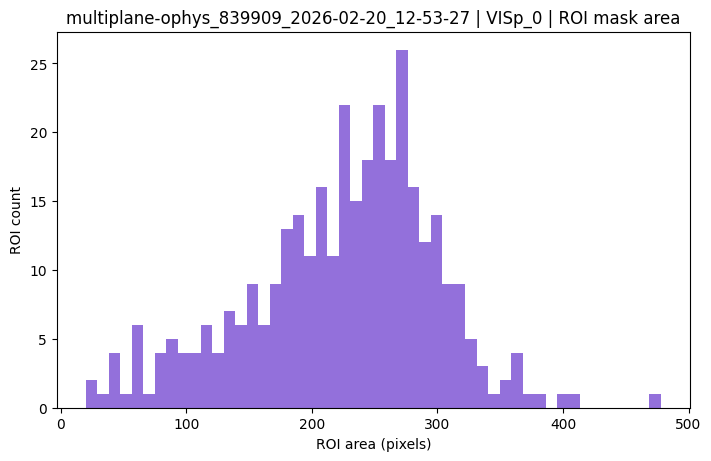

In [6]:
area_col = "roi_area_pix_mask" if "roi_area_pix_mask" in roi_snr else "roi_area_pix"
if area_col not in roi_snr:
    print("ROI area metrics are not available. Set LOAD_ROI_MASK_METRICS = True and rerun the load/calculation cells.")
else:
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ax.hist(roi_snr[area_col].dropna(), bins=50, color="mediumpurple")
    ax.set(
        title=f"{session_id} | {PLANE} | ROI mask area",
        xlabel="ROI area (pixels)",
        ylabel="ROI count",
    )
    plt.show()


### ROI extraction: circularity and elongation

Formulas:

$$
\mathrm{circularity} = \frac{4\pi A}{P^2}
$$

$$
\mathrm{elongation} = \sqrt{\frac{\lambda_{major}}{\lambda_{minor}}}
$$

where $A$ is mask area, $P$ is mask perimeter, and $\lambda$ values are eigenvalues of the pixel-coordinate covariance matrix.

Plain language: circularity is higher for compact round ROIs and lower for irregular or process-like shapes. Elongation is near 1 for round shapes and increases for stretched masks. These metrics capture geometry, which event SNR cannot see; they are useful for separating soma-like ROIs from dendrites, artifacts, or merged/partial masks.


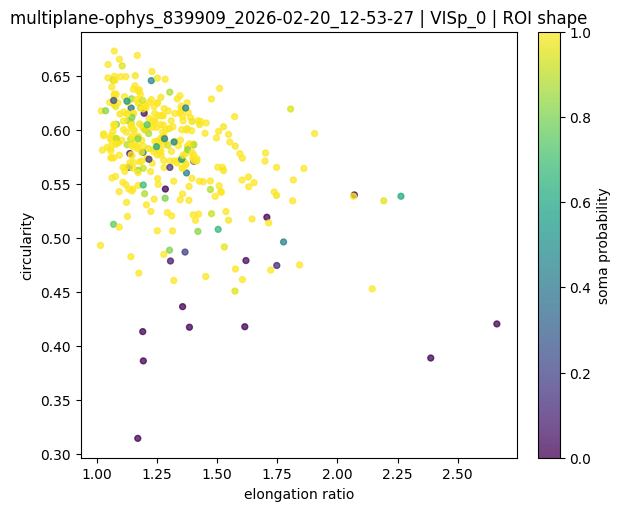

In [7]:
required = {"roi_circularity", "roi_elongation"}
if not required.issubset(roi_snr.columns):
    print("ROI shape metrics are not available. Set LOAD_ROI_MASK_METRICS = True and rerun the load/calculation cells.")
else:
    shape_ok = roi_snr["roi_circularity"].notna() & roi_snr["roi_elongation"].notna()
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    scatter = ax.scatter(
        roi_snr.loc[shape_ok, "roi_elongation"],
        roi_snr.loc[shape_ok, "roi_circularity"],
        c=roi_snr.loc[shape_ok, "soma_probability"] if "soma_probability" in roi_snr else None,
        cmap="viridis",
        s=18,
        alpha=0.75,
    )
    if "soma_probability" in roi_snr:
        fig.colorbar(scatter, ax=ax, label="soma probability")
    ax.set(
        title=f"{session_id} | {PLANE} | ROI shape",
        xlabel="elongation ratio",
        ylabel="circularity",
    )
    plt.show()


### ROI extraction: classifier confidence and margin

Formulas:

$$
\mathrm{confidence} = \max(p_{soma}, p_{dendrite})
$$

$$
\mathrm{margin} = |p_{soma} - p_{dendrite}|
$$

Plain language: confidence asks whether the classifier strongly preferred any class; margin asks whether soma versus dendrite was ambiguous. This captures classification certainty, which is distinct from morphology and signal quality. A high-SNR ROI can still be ambiguous about whether it is soma or dendrite.


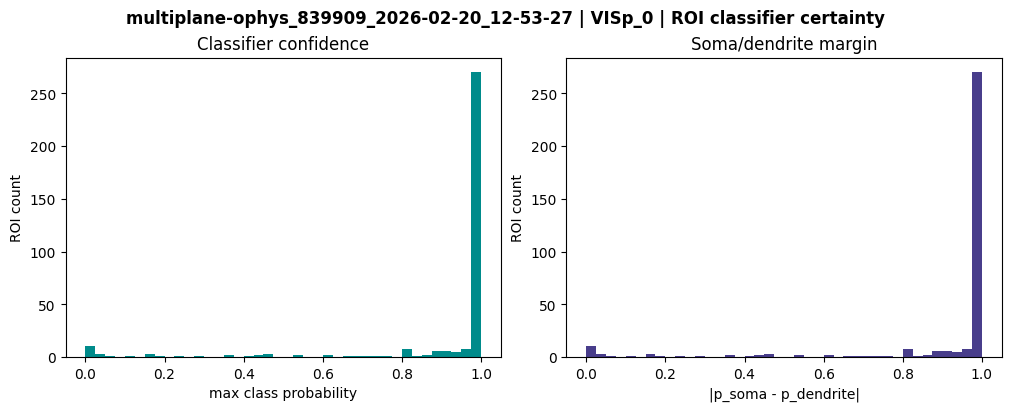

In [8]:
required = {"roi_classifier_confidence", "roi_classifier_margin"}
if not required.issubset(roi_snr.columns):
    print("ROI classifier certainty metrics are not available. Set LOAD_ROI_MASK_METRICS = True and rerun the load/calculation cells.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
    axes[0].hist(roi_snr["roi_classifier_confidence"].dropna(), bins=np.linspace(0, 1, 41), color="darkcyan")
    axes[0].set(title="Classifier confidence", xlabel="max class probability", ylabel="ROI count")
    axes[1].hist(roi_snr["roi_classifier_margin"].dropna(), bins=np.linspace(0, 1, 41), color="darkslateblue")
    axes[1].set(title="Soma/dendrite margin", xlabel="|p_soma - p_dendrite|", ylabel="ROI count")
    fig.suptitle(f"{session_id} | {PLANE} | ROI classifier certainty", fontweight="bold")
    plt.show()


### dF/F signal quality: robust event SNR

Formula:

$$
\mathrm{SNR}_{event} = \frac{P_{95}(\Delta F/F) - P_{50}(\Delta F/F)}{\sigma_{noise}}
$$

with

$$
\sigma_{noise} = 1.4826 \cdot \mathrm{median}\left(|r - \mathrm{median}(r)|\right), \quad r = \Delta F/F - G_{\sigma}(\Delta F/F)
$$

Plain language: this compares a robust high-activity amplitude to fast residual noise. It captures whether the trace has calcium-scale fluctuations that are large relative to noise. Unlike the exceptional-event metric, it summarizes the trace distribution rather than focusing only on the single most improbable run.


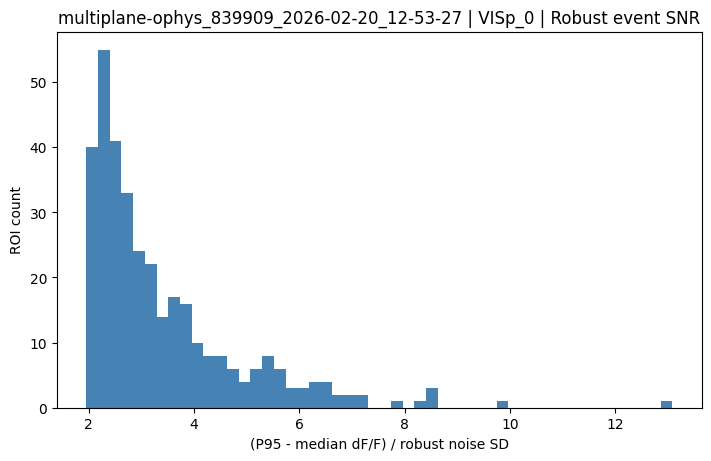

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["robust_event_snr"].dropna(), bins=50, color="steelblue")
ax.set(
    title=f"{session_id} | {PLANE} | Robust event SNR",
    xlabel="(P95 - median dF/F) / robust noise SD",
    ylabel="ROI count",
)
plt.show()


### dF/F signal quality: signal amplitude versus noise

Formulas:

$$
\mathrm{signal\ amplitude} = P_{95}(\Delta F/F) - P_{50}(\Delta F/F)
$$

$$
\mathrm{noise\ SD} = \sigma_{noise}
$$

Plain language: this separates the numerator and denominator of robust event SNR. It is important because the same SNR can arise from a genuinely large event amplitude or from an unusually low noise estimate. This plot helps identify whether high-SNR ROIs are driven by strong calcium signals, low noise, or both.


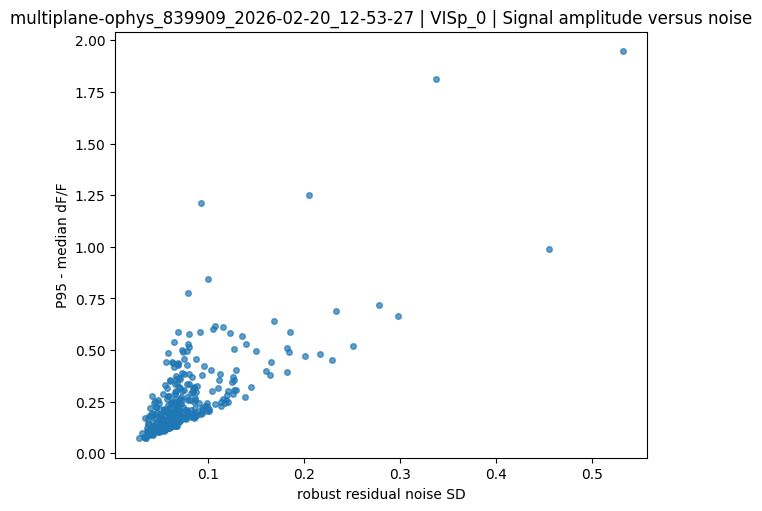

In [10]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    roi_snr["robust_event_noise_sd"],
    roi_snr["robust_event_signal_amp"],
    s=16,
    alpha=0.7,
)
ax.set(
    title=f"{session_id} | {PLANE} | Signal amplitude versus noise",
    xlabel="robust residual noise SD",
    ylabel="P95 - median dF/F",
)
plt.show()


### dF/F signal quality: exceptional-event score

Formula:

$$
z_t = \frac{x_t - \hat{x}_{mode}}{3\sigma_{lower}}
$$

$$
\mathrm{fitness} = \min_t \sum_{k=0}^{N-1} \log\left[P(Z > z_{t+k})\right]
$$

$$
\mathrm{exceptional\ event\ score} = -\mathrm{fitness}
$$

Plain language: this asks whether there is at least one sustained positive run that is statistically unlikely under a lower-tail baseline-noise model. It captures the presence of a convincing event even if the rest of the trace is quiet. This is different from robust event SNR, which summarizes broad trace amplitude rather than the strongest unlikely run.


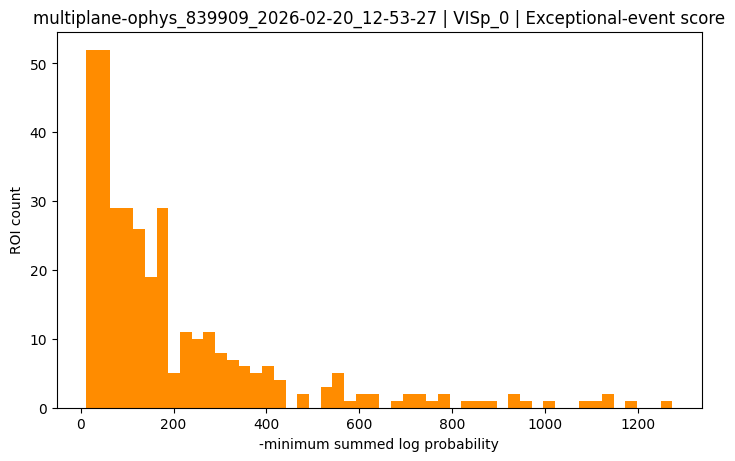

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["exceptional_event_score"].dropna(), bins=50, color="darkorange")
ax.set(
    title=f"{session_id} | {PLANE} | Exceptional-event score",
    xlabel="-minimum summed log probability",
    ylabel="ROI count",
)
plt.show()


### dF/F signal quality: robust SNR versus exceptional-event score

Comparison:

$$
\mathrm{SNR}_{event} \quad \mathrm{versus} \quad -\min_t \sum_{k=0}^{N-1} \log\left[P(Z > z_{t+k})\right]
$$

Plain language: this compares a distribution-wide amplitude-to-noise summary with a single strongest-event improbability score. It is important because these metrics can disagree: one strong artifact can produce a high exceptional-event score, while frequent moderate activity can produce high robust SNR without one dominant event.


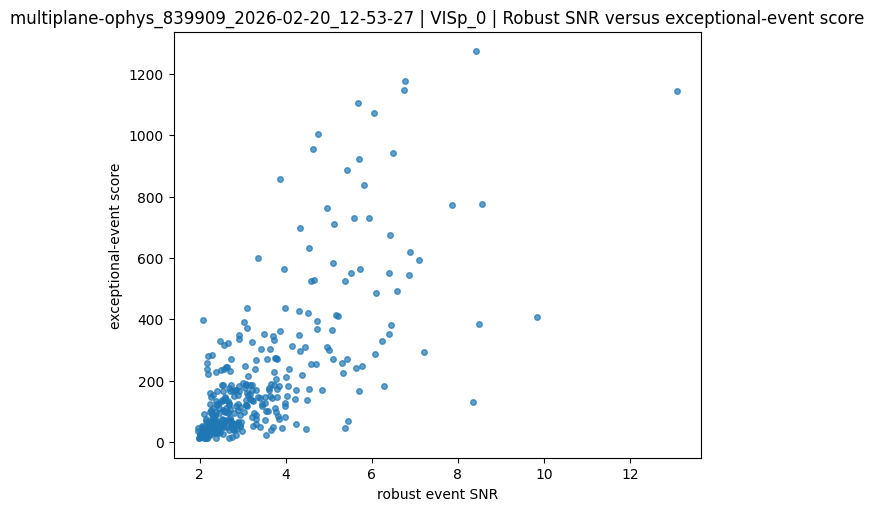

In [12]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    roi_snr["robust_event_snr"],
    roi_snr["exceptional_event_score"],
    s=16,
    alpha=0.7,
)
ax.set(
    title=f"{session_id} | {PLANE} | Robust SNR versus exceptional-event score",
    xlabel="robust event SNR",
    ylabel="exceptional-event score",
)
plt.show()


### dF/F signal quality: early-versus-late drift

Formula:

$$
\Delta_{drift} = \mathrm{median}(x_{last\ 10\%}) - \mathrm{median}(x_{first\ 10\%})
$$

$$
\mathrm{absolute\ drift\ in\ noise\ units} = \frac{|\Delta_{drift}|}{\sigma_{noise}}
$$

Plain language: this captures slow baseline movement across the session. It is important because an ROI can have high event SNR while still drifting enough to complicate trial comparisons or longitudinal interpretation. Lower values indicate a more stable dF/F baseline.


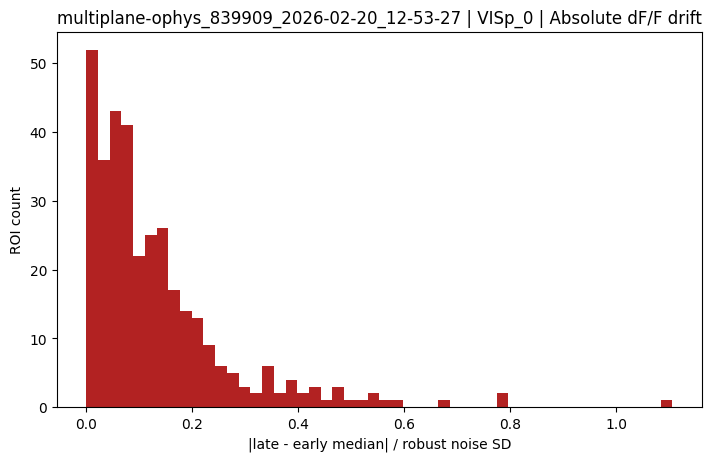

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["dff_abs_drift_noise_units"].dropna(), bins=50, color="firebrick")
ax.set(
    title=f"{session_id} | {PLANE} | Absolute dF/F drift",
    xlabel="|late - early median| / robust noise SD",
    ylabel="ROI count",
)
plt.show()


### dF/F signal quality: baseline-bin instability

Formula:

$$
b_i = \mathrm{median}(x \; \mathrm{within\ session\ bin}\; i)
$$

$$
\mathrm{baseline\ range\ in\ noise\ units} = \frac{\max_i(b_i) - \min_i(b_i)}{\sigma_{noise}}
$$

Plain language: this generalizes the early-versus-late drift check by looking across multiple time bins. It captures non-monotonic baseline instability that early/late drift can miss, such as a mid-session excursion or recovery.


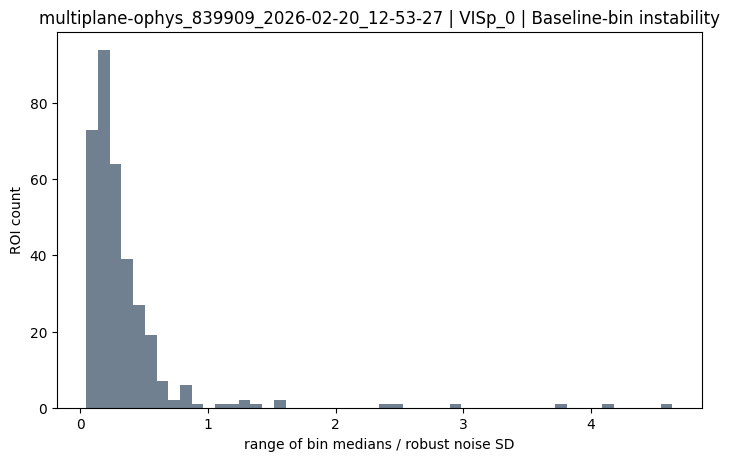

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["dff_baseline_range_noise_units"].dropna(), bins=50, color="slategray")
ax.set(
    title=f"{session_id} | {PLANE} | Baseline-bin instability",
    xlabel="range of bin medians / robust noise SD",
    ylabel="ROI count",
)
plt.show()


### Event extraction quality: OASIS event-onset rate

Formula:

$$
\mathrm{event\ onset\ count} = \sum_t \mathbf{1}\{e_t > \theta\ \land\ e_{t-1} \le \theta\}
$$

$$
\mathrm{event\ onset\ rate} = \frac{\mathrm{event\ onset\ count}}{T_{session}}
$$

Plain language: this counts transitions into positive extracted-event periods, rather than every positive event sample. It captures how frequently the event extractor detects new events. It is not a calibrated electrophysiological firing rate, but it is useful for identifying silent ROIs, hyperactive ROIs, or extraction artifacts.


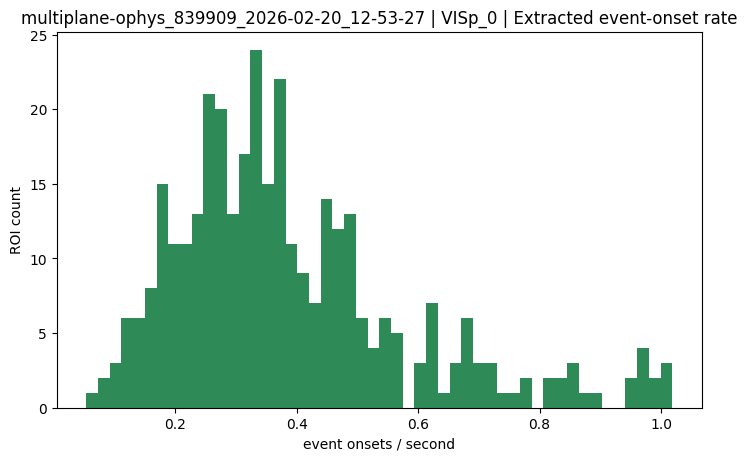

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["event_onset_rate_hz"].dropna(), bins=50, color="seagreen")
ax.set(
    title=f"{session_id} | {PLANE} | Extracted event-onset rate",
    xlabel="event onsets / second",
    ylabel="ROI count",
)
plt.show()


### Event extraction quality: event-triggered dF/F SNR

Formula:

$$
\bar{x}_{event}(\tau) = \mathrm{median}_{events}\left[x(t_{event}+\tau) - \mathrm{median}(x_{pre-event})\right]
$$

$$
\mathrm{event\ triggered\ SNR} = \frac{\max_{\tau \ge 0}\bar{x}_{event}(\tau)}{\sigma_{noise}}
$$

Plain language: this asks whether extracted OASIS events are actually accompanied by a visible calcium transient in dF/F. It captures event-extraction quality, not just trace quality. A high event rate with low event-triggered SNR suggests the event detector may be responding to noise or small fluctuations.


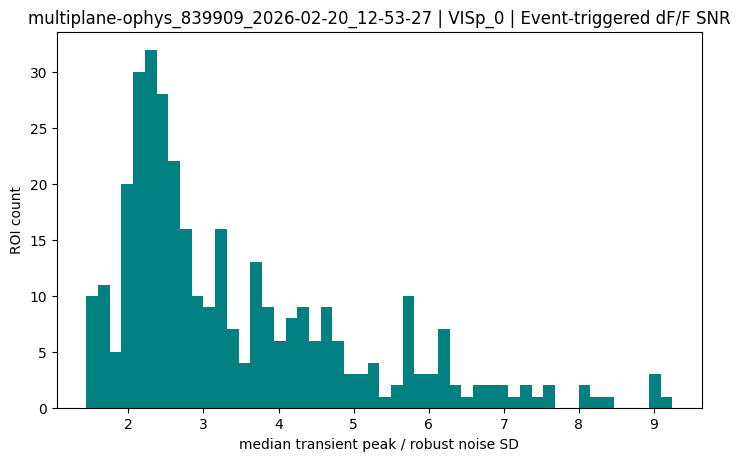

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["event_triggered_dff_snr"].dropna(), bins=50, color="teal")
ax.set(
    title=f"{session_id} | {PLANE} | Event-triggered dF/F SNR",
    xlabel="median transient peak / robust noise SD",
    ylabel="ROI count",
)
plt.show()


### Event extraction quality: empirical calcium decay

Formula:

For the post-peak median event-triggered transient, fit

$$
\log \bar{x}_{event}(t) = \alpha - \frac{t}{\tau}
$$

so

$$
\tau = -\frac{1}{\mathrm{slope}}
$$

Plain language: this estimates the decay time constant of the average calcium transient and reports the exponential-fit $R^2$. It captures calcium-kernel plausibility, which neither event rate nor event SNR captures. Tau is only interpretable when the fit $R^2$ is reasonably high; low $R^2$ means a single exponential is a poor description of that ROI's average transient.


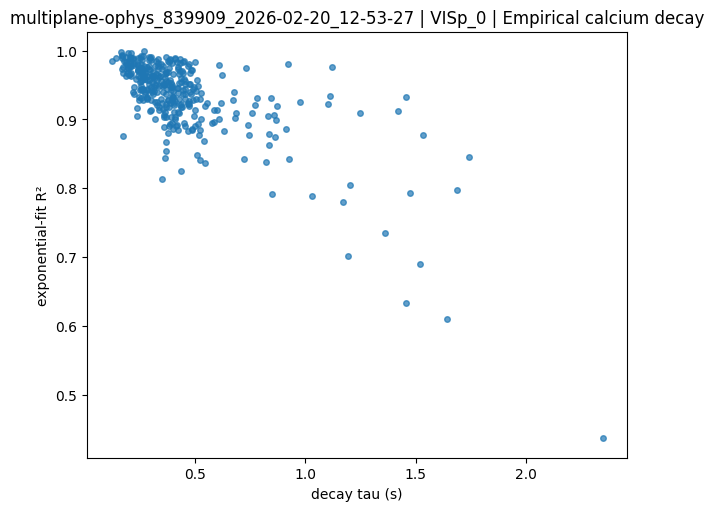

In [17]:
kernel_ok = roi_snr["calcium_kernel_tau_s"].notna() & roi_snr["calcium_kernel_decay_r2"].notna()
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    roi_snr.loc[kernel_ok, "calcium_kernel_tau_s"],
    roi_snr.loc[kernel_ok, "calcium_kernel_decay_r2"],
    s=16,
    alpha=0.7,
)
ax.set(
    title=f"{session_id} | {PLANE} | Empirical calcium decay",
    xlabel="decay tau (s)",
    ylabel="exponential-fit R²",
)
plt.show()


In [18]:
ranked = roi_snr.sort_values("robust_event_snr", ascending=False)
display(ranked[[
    "roi_index",
    "soma_probability",
    "roi_area_pix_mask",
    "roi_circularity",
    "robust_event_snr",
    "dff_abs_drift_noise_units",
    "robust_event_signal_amp",
    "robust_event_noise_sd",
    "exceptional_event_fitness",
    "exceptional_event_score",
    "event_onset_rate_hz",
    "event_triggered_dff_snr",
    "calcium_kernel_tau_s",
    "calcium_kernel_decay_r2",
]].head(25))


,roi_index,soma_probability,roi_area_pix_mask,roi_circularity,robust_event_snr,dff_abs_drift_noise_units,robust_event_signal_amp,robust_event_noise_sd,exceptional_event_fitness,exceptional_event_score,event_onset_rate_hz,event_triggered_dff_snr,calcium_kernel_tau_s,calcium_kernel_decay_r2
153,153,0.029021,280,0.578334,13.087127,0.277247,1.213233,0.092704,-1142.489639,1142.489639,0.848203,3.740553,0.832912,0.905599
287,287,0.999851,303,0.625840,9.831788,0.076645,0.777833,0.079114,-408.732791,408.732791,0.862074,3.285693,0.617846,0.924350
13,13,0.944349,57,0.619622,8.567529,0.779394,0.587289,0.068548,-777.042497,777.042497,0.978358,1.573196,2.348622,0.436674
154,154,0.999998,199,0.574084,8.487575,0.198307,0.843454,0.099375,-383.217085,383.217085,0.961713,2.153243,0.732411,0.975012
80,80,0.999266,331,0.618600,8.413885,0.320595,0.486433,0.057813,-1273.979064,1273.979064,0.494958,5.924334,0.353561,0.915484
207,207,0.048118,283,0.615700,8.351869,1.106007,0.540618,0.064730,-130.322150,130.322150,0.856525,1.946413,0.779312,0.930977
59,59,0.999983,328,0.612994,7.864872,0.246001,0.441820,0.056176,-773.172480,773.172480,0.513684,6.112110,0.328485,0.921146
199,199,0.999266,268,0.649650,7.216401,0.134024,0.577725,0.080057,-293.653453,293.653453,0.652855,3.973322,0.862129,0.874540
242,242,0.999994,248,0.569112,7.108980,0.116353,0.444355,0.062506,-594.527203,594.527203,0.491722,5.671414,0.209045,0.988431
147,147,0.999869,233,0.564808,6.894971,0.172105,0.437781,0.063493,-619.458901,619.458901,0.411271,6.147030,0.303391,0.963032


In [19]:
safe_session = "".join(c if c.isalnum() or c in "._-" else "_" for c in str(session_id))
output_csv = OUTPUT_DIR / f"{safe_session}_{PLANE}_roi_signal_quality_metrics.csv"
roi_snr.to_csv(output_csv, index=False)
print(output_csv)


/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics/multiplane-ophys_839909_2026-02-20_12-53-27_VISp_0_roi_signal_quality_metrics.csv
